In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/VivimedLabs_10Years.csv')
display(df.head())

,Date,VIVIMEDLAB.NS.Open,VIVIMEDLAB.NS.High,VIVIMEDLAB.NS.Low,VIVIMEDLAB.NS.Close,VIVIMEDLAB.NS.Volume
0,01-01-2016,89.400002,90.360001,88.019997,88.669998,316870.0
1,04-01-2016,88.599998,90.489998,87.239998,88.610001,255275.0
2,05-01-2016,88.629997,92.800003,88.629997,92.070000,813810.0
3,06-01-2016,92.480003,94.599998,91.019997,92.769997,521480.0
4,07-01-2016,91.540001,92.410004,89.029999,89.860001,207240.0


## Data Preparation for Dashboard
First, let's ensure the 'Date' column is in datetime format and set it as the DataFrame index. This is crucial for time-series analysis and plotting.

In [ ]:
# Convert 'Date' column to datetime and set as index
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df.set_index('Date', inplace=True)

# Rename columns for easier access (optional but good practice for plotting)
df.columns = ['Open', 'High', 'Low', 'Close', 'Volume']

display(df.head())

,Open,High,Low,Close,Volume
Date,,,,,
2016-01-01,89.400002,90.360001,88.019997,88.669998,316870.0
2016-01-04,88.599998,90.489998,87.239998,88.610001,255275.0
2016-01-05,88.629997,92.800003,88.629997,92.070000,813810.0
2016-01-06,92.480003,94.599998,91.019997,92.769997,521480.0
2016-01-07,91.540001,92.410004,89.029999,89.860001,207240.0


## Key Performance Indicators (KPIs) - 'Cards'
Let's calculate and display some important metrics as 'cards' (textual summaries). These provide a quick overview of the data.

In [ ]:
total_volume = df['Volume'].sum()
avg_close_price = df['Close'].mean()
max_close_price = df['Close'].max()
min_close_price = df['Close'].min()

print(f"Total Trading Volume: {total_volume:,.0f}")
print(f"Average Closing Price: {avg_close_price:.2f}")
print(f"Highest Closing Price: {max_close_price:.2f}")
print(f"Lowest Closing Price: {min_close_price:.2f}")

Total Trading Volume: 879,410,418
Average Closing Price: 33.73
Highest Closing Price: 143.20
Lowest Closing Price: 4.95


## Historical Graph: Closing Price Over Time
This line chart shows the trend of the closing price over the entire period.

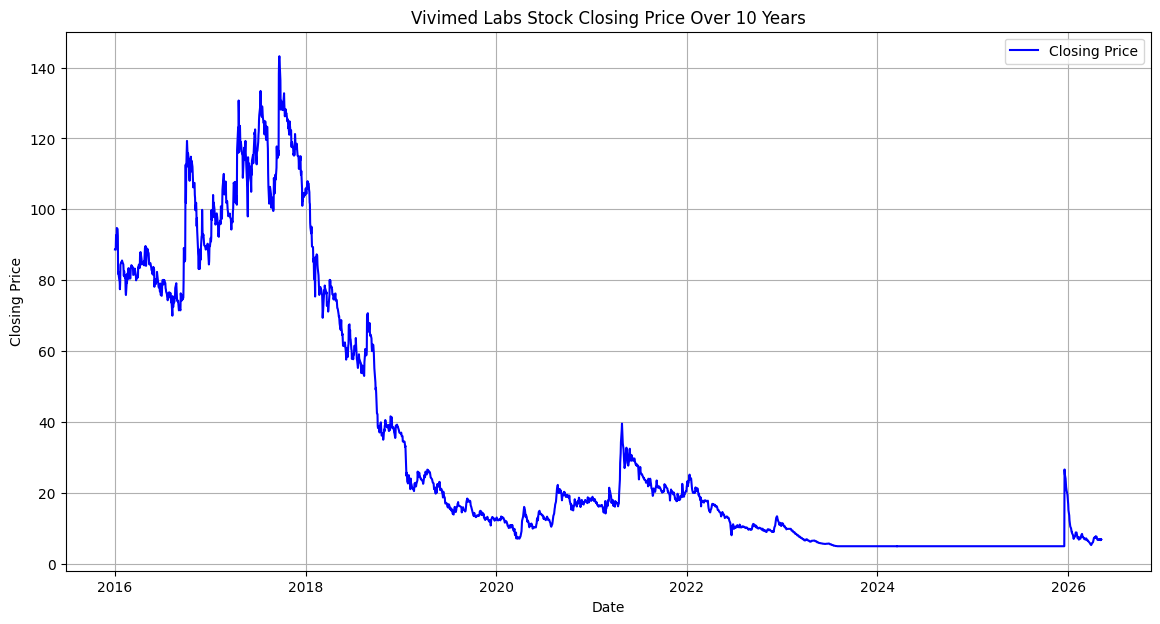

In [ ]:
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Close'], label='Closing Price', color='blue')
plt.title('Vivimed Labs Stock Closing Price Over 10 Years')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.grid(True)
plt.legend()
plt.show()

## Multi-Line Chart: Open, High, Low, Close Prices
This chart visualizes the daily open, high, low, and close prices, providing a comprehensive view of price movements.

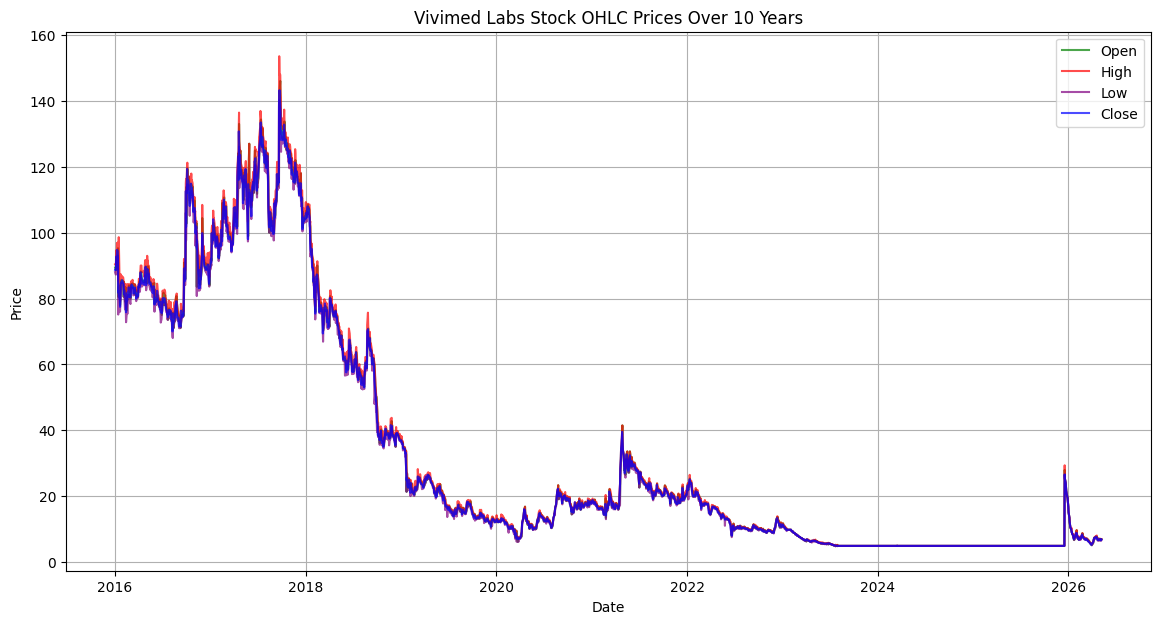

In [ ]:
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Open'], label='Open', color='green', alpha=0.7)
plt.plot(df.index, df['High'], label='High', color='red', alpha=0.7)
plt.plot(df.index, df['Low'], label='Low', color='purple', alpha=0.7)
plt.plot(df.index, df['Close'], label='Close', color='blue', alpha=0.7)
plt.title('Vivimed Labs Stock OHLC Prices Over 10 Years')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.legend()
plt.show()

## Bar Chart: Average Monthly Trading Volume
This bar chart illustrates the average trading volume for each month across all years, highlighting monthly activity patterns.

/tmp/ipykernel_885/2634852630.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_monthly_volume.index, y=avg_monthly_volume.values, palette='viridis')


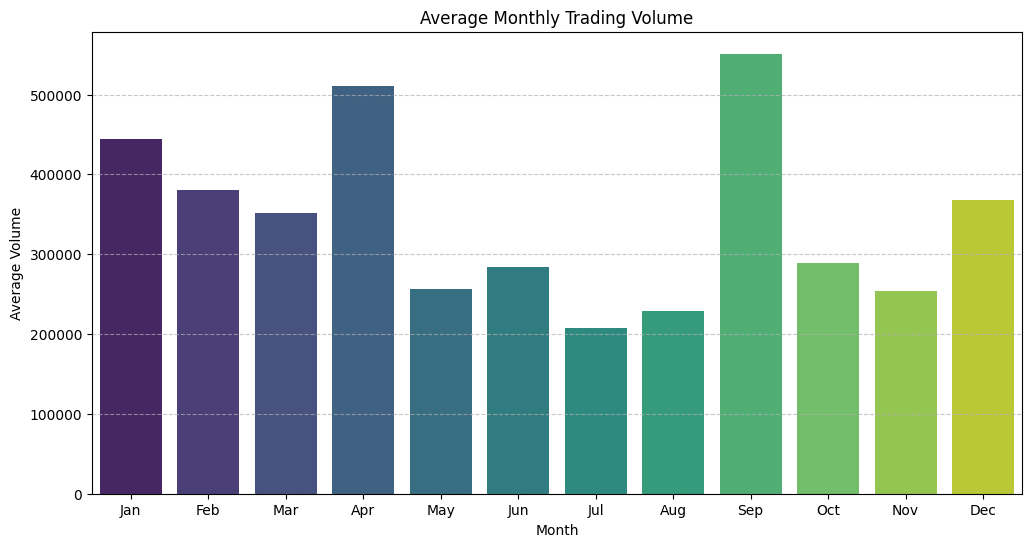

In [ ]:
df['Month'] = df.index.month
avg_monthly_volume = df.groupby('Month')['Volume'].mean()

plt.figure(figsize=(12, 6))
sns.barplot(x=avg_monthly_volume.index, y=avg_monthly_volume.values, palette='viridis')
plt.title('Average Monthly Trading Volume')
plt.xlabel('Month')
plt.ylabel('Average Volume')
plt.xticks(ticks=np.arange(12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Heatmap: Correlation Matrix
A heatmap visualizes the correlation between different numerical features in the dataset. This helps in understanding relationships between variables.

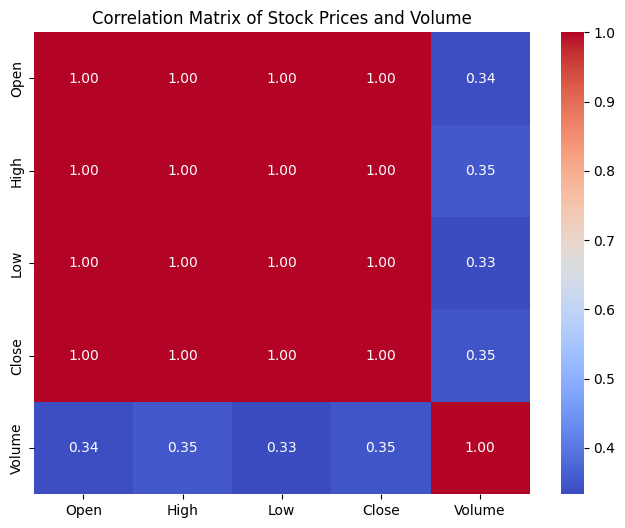

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[['Open', 'High', 'Low', 'Close', 'Volume']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Stock Prices and Volume')
plt.show()

## Donut Chart: Annual Volume Distribution
This donut chart shows the distribution of total trading volume across different years. We can also make this a pie chart depending on preference.

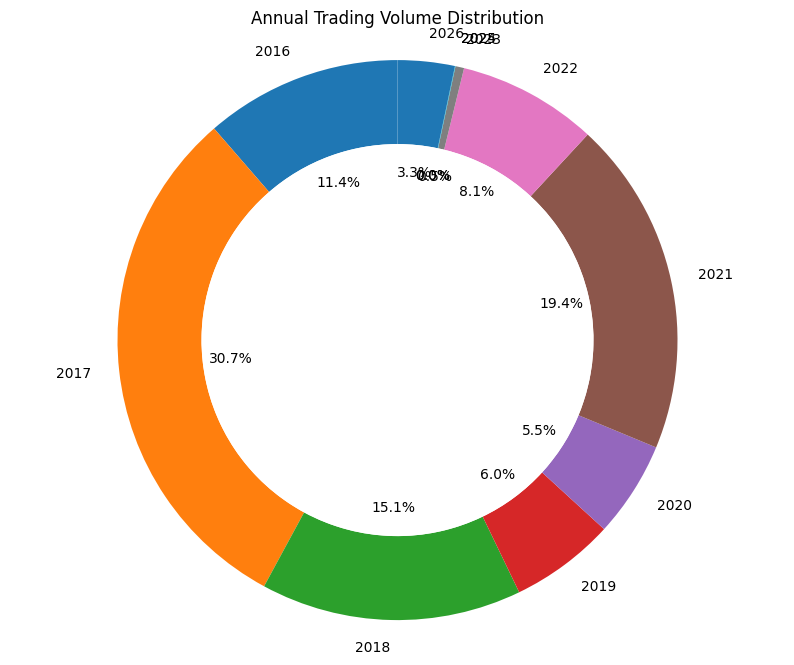

In [ ]:
df['Year'] = df.index.year
annual_volume = df.groupby('Year')['Volume'].sum()

plt.figure(figsize=(10, 8))
plt.pie(annual_volume, labels=annual_volume.index, autopct='%1.1f%%', startangle=90, wedgeprops=dict(width=0.3))
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title('Annual Trading Volume Distribution')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

## Pie Chart: Annual Volume Distribution
This is another representation of the annual volume distribution, similar to the donut chart, but as a standard pie chart.

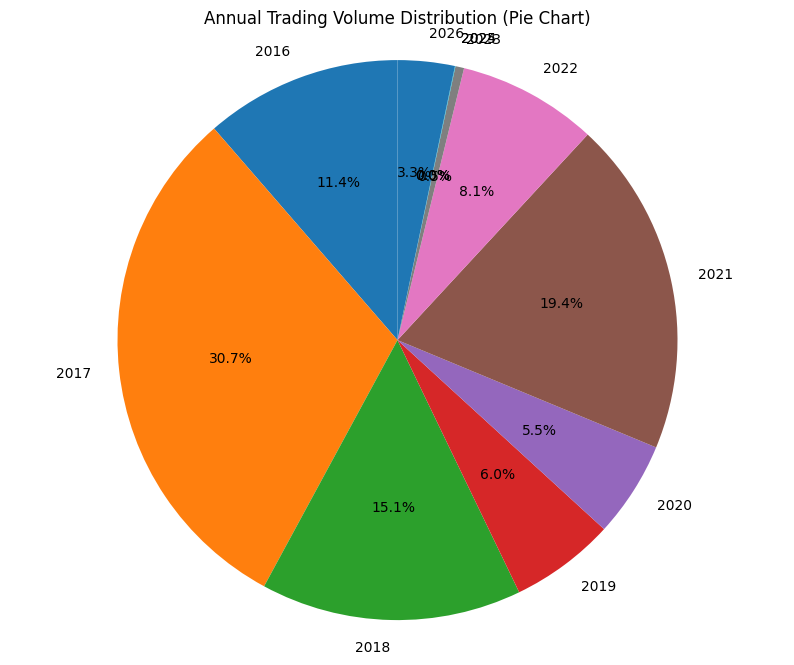

In [ ]:
plt.figure(figsize=(10, 8))
plt.pie(annual_volume, labels=annual_volume.index, autopct='%1.1f%%', startangle=90)
plt.title('Annual Trading Volume Distribution (Pie Chart)')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

## Regenerating All Visualizations for Display

## Closing Price with Moving Averages
This chart displays the closing price along with 50-day and 200-day Simple Moving Averages (SMA). Moving averages help to smooth out price fluctuations and identify trends over different timeframes.

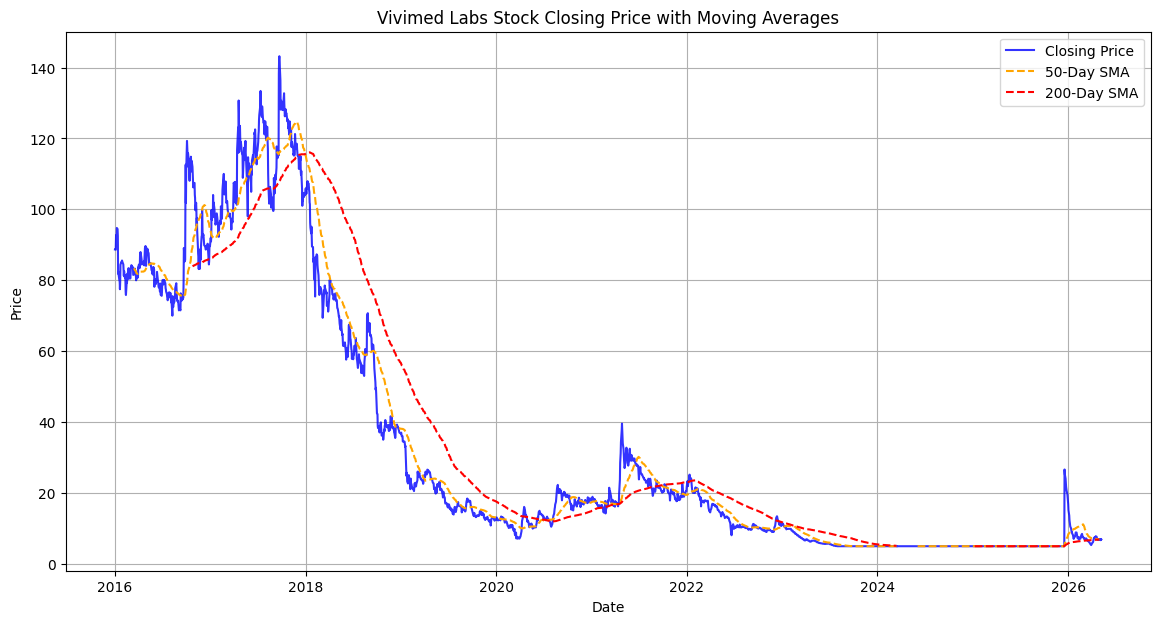

In [ ]:
df['SMA_50'] = df['Close'].rolling(window=50).mean()
df['SMA_200'] = df['Close'].rolling(window=200).mean()

plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Close'], label='Closing Price', color='blue', alpha=0.8)
plt.plot(df.index, df['SMA_50'], label='50-Day SMA', color='orange', linestyle='--')
plt.plot(df.index, df['SMA_200'], label='200-Day SMA', color='red', linestyle='--')
plt.title('Vivimed Labs Stock Closing Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.legend()
plt.show()

## Comprehensive Stock Analysis Dashboard

This section integrates all the previously generated visualizations and Key Performance Indicators (KPIs) into a single, well-organized dashboard for a holistic view of Vivimed Labs stock performance. The dashboard is designed to be professional and attractive, providing a quick and insightful overview.

/tmp/ipykernel_885/1055232587.py:113: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



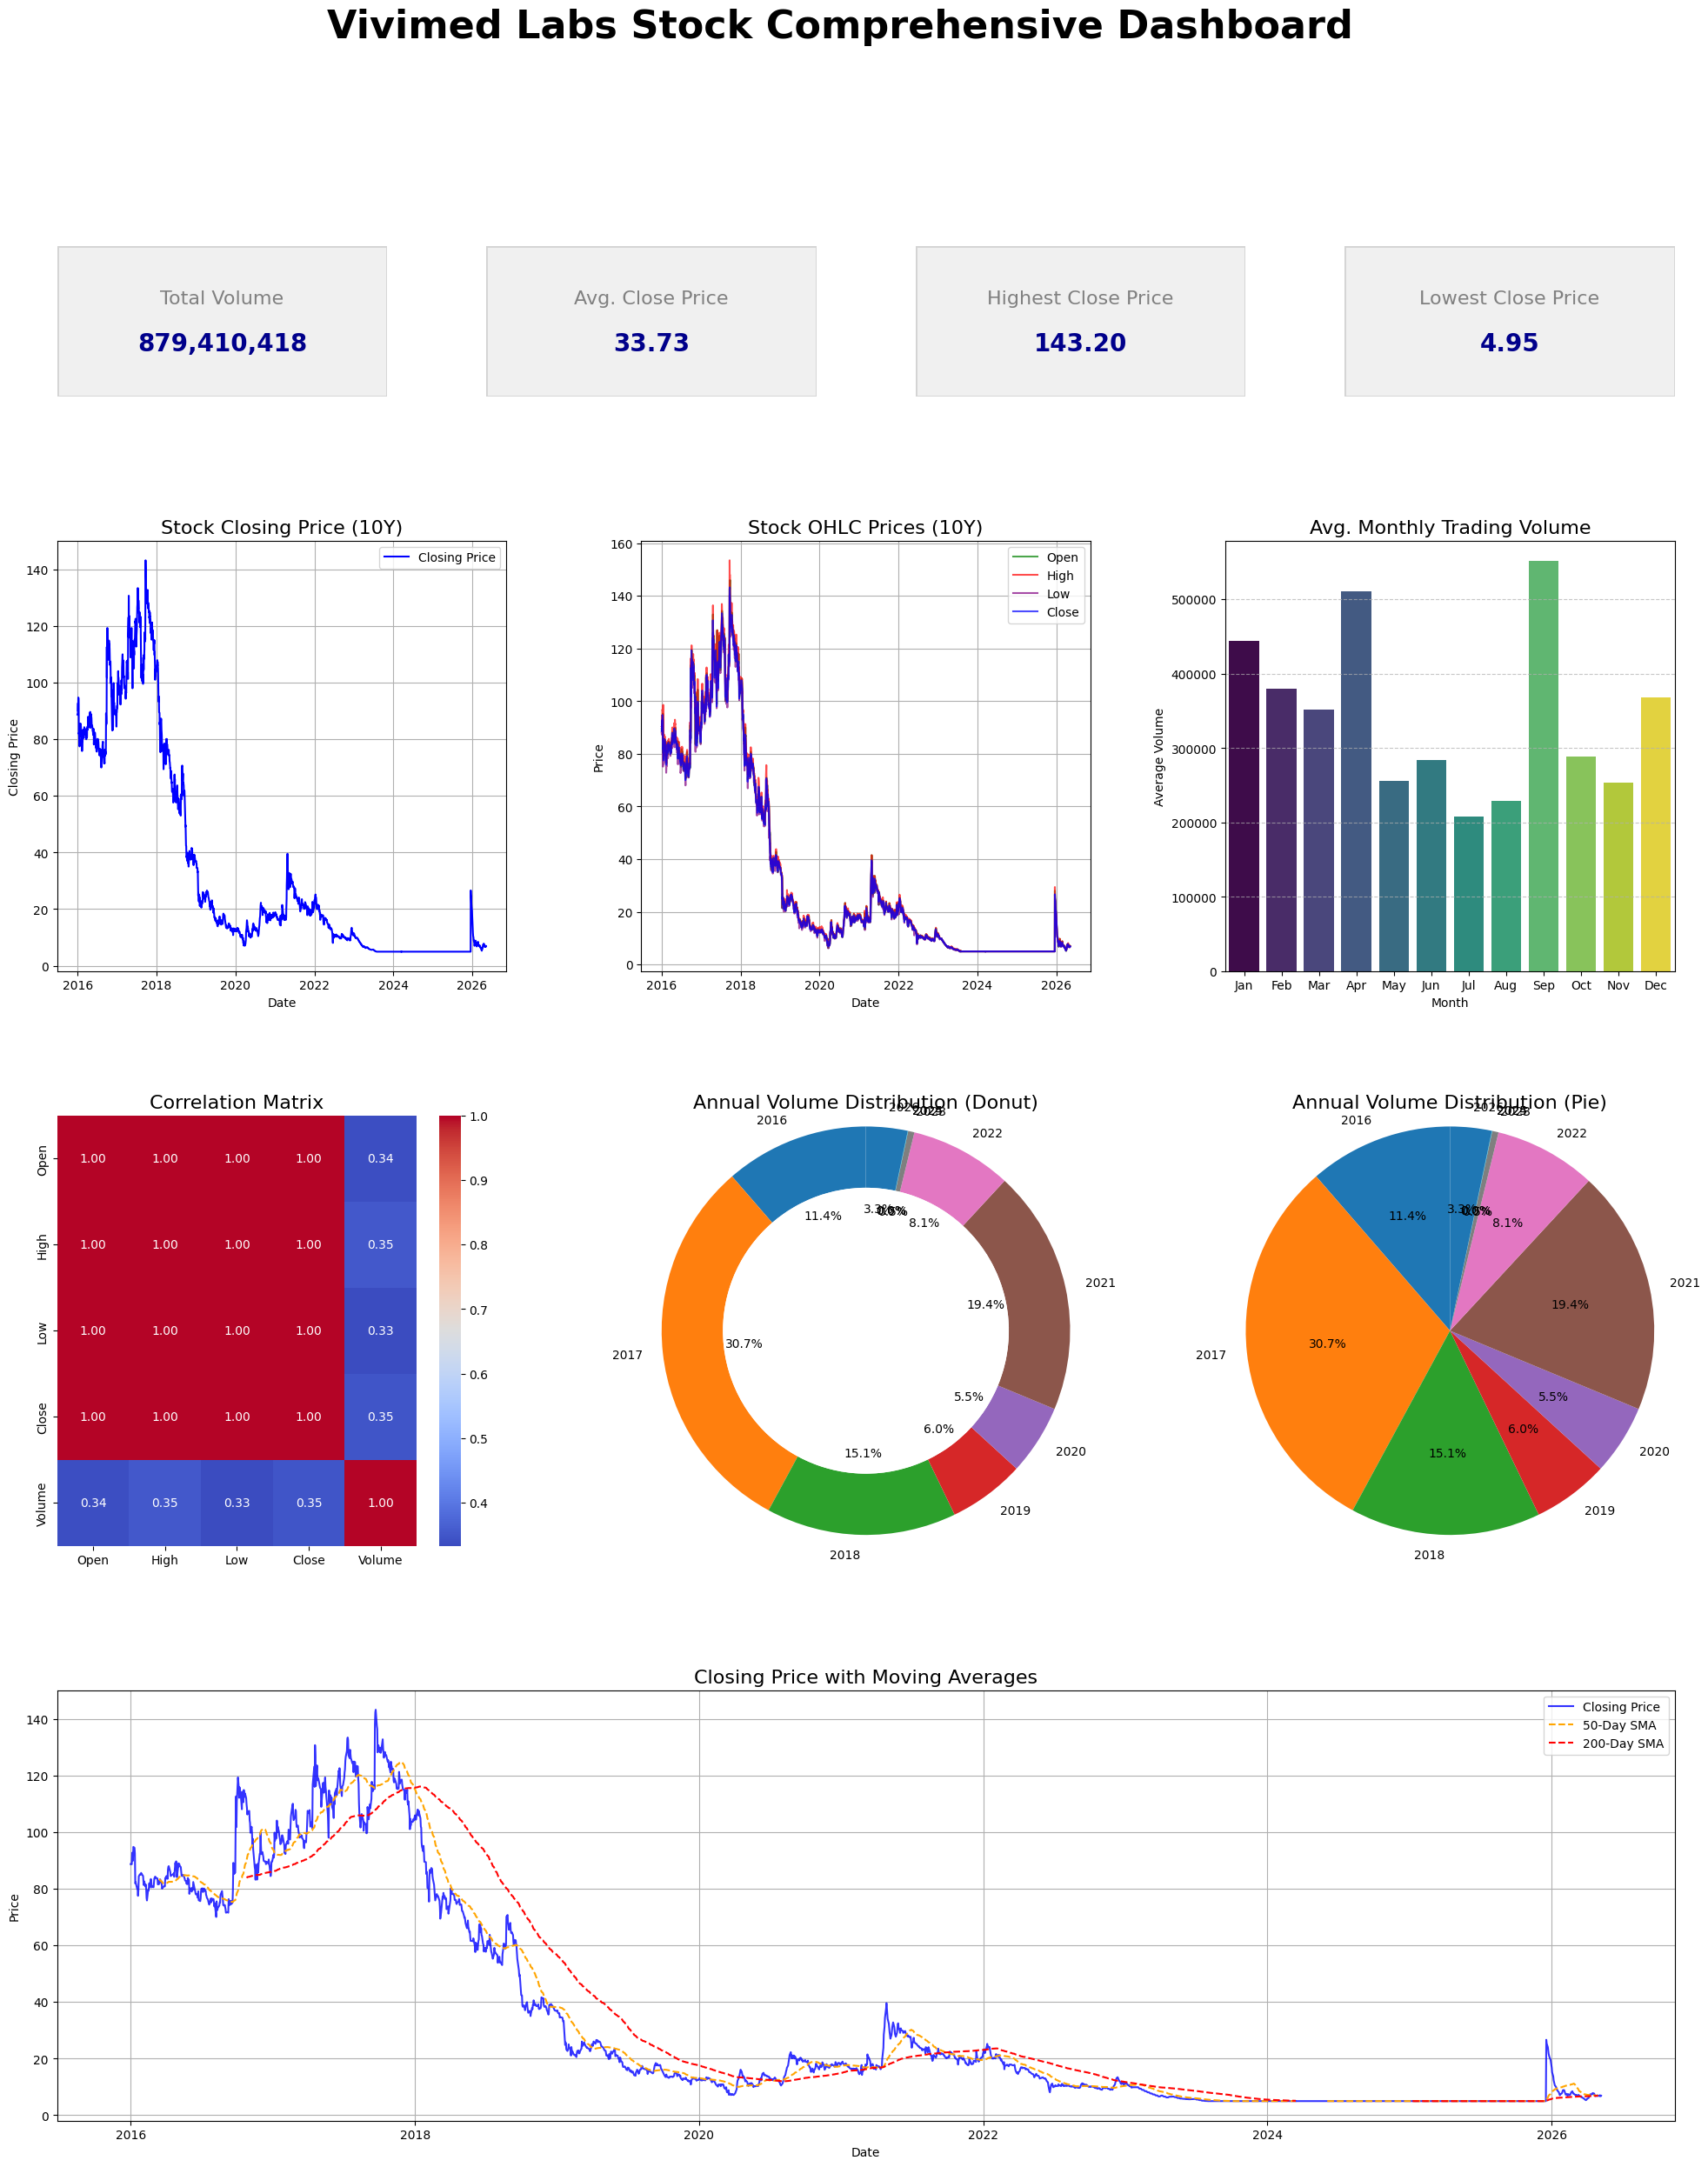

In [ ]:
import matplotlib.gridspec as gridspec

# Recalculate monthly average volume for the bar chart as 'Month' column might have been dropped or modified
df['Month'] = df.index.month
avg_monthly_volume = df.groupby('Month')['Volume'].mean()

# Recalculate annual volume for donut/pie charts
df['Year'] = df.index.year
annual_volume = df.groupby('Year')['Volume'].sum()

# Recalculate SMA for the moving average chart
df['SMA_50'] = df['Close'].rolling(window=50).mean()
df['SMA_200'] = df['Close'].rolling(window=200).mean()

# --- Create the Dashboard --- #

fig = plt.figure(figsize=(24, 28)) # Adjusted height for 3-3-1 layout
gs = gridspec.GridSpec(4, 3, figure=fig, height_ratios=[0.7, 2, 2, 2], hspace=0.4, wspace=0.3) # 4 rows, 3 columns

# Row 0: KPIs (dedicated space for better layout)
kpi_gs = gridspec.GridSpecFromSubplotSpec(1, 4, subplot_spec=gs[0, :], wspace=0.3)

total_volume = df['Volume'].sum()
avg_close_price = df['Close'].mean()
max_close_price = df['Close'].max()
min_close_price = df['Close'].min()

kpi_data = {
    "Total Volume": f"{total_volume:,.0f}",
    "Avg. Close Price": f"{avg_close_price:.2f}",
    "Highest Close Price": f"{max_close_price:.2f}",
    "Lowest Close Price": f"{min_close_price:.2f}"
}

for i, (label, value) in enumerate(kpi_data.items()):
    ax_kpi = fig.add_subplot(kpi_gs[0, i])
    ax_kpi.set_facecolor('#f0f0f0') # Light gray background for the card
    ax_kpi.text(0.5, 0.65, label, horizontalalignment='center', verticalalignment='center',
                fontsize=16, color='gray', transform=ax_kpi.transAxes)
    ax_kpi.text(0.5, 0.35, value, horizontalalignment='center', verticalalignment='center',
                fontsize=20, fontweight='bold', color='darkblue', transform=ax_kpi.transAxes)
    ax_kpi.set_xticks([])
    ax_kpi.set_yticks([])
    ax_kpi.spines['top'].set_visible(False)
    ax_kpi.spines['right'].set_visible(False)
    ax_kpi.spines['left'].set_visible(False)
    ax_kpi.spines['bottom'].set_visible(False)
    # Add a border for card effect
    rect = plt.Rectangle((0, 0), 1, 1, transform=ax_kpi.transAxes,
                         linewidth=2, edgecolor='lightgray', facecolor='none')
    ax_kpi.add_patch(rect)


# Add a main title for the entire dashboard
fig.text(0.5, 0.97, 'Vivimed Labs Stock Comprehensive Dashboard', ha='center', va='center', fontsize=32, fontweight='bold')

# Row 1: Historical Graph, OHLC Multi-Line Chart, and Monthly Volume Bar Chart (3 charts)
ax1 = fig.add_subplot(gs[1, 0]) # Historical Graph
ax1.plot(df.index, df['Close'], label='Closing Price', color='blue')
ax1.set_title('Stock Closing Price (10Y)', fontsize=16)
ax1.set_xlabel('Date')
ax1.set_ylabel('Closing Price')
ax1.grid(True)
ax1.legend()

ax2 = fig.add_subplot(gs[1, 1]) # OHLC Multi-Line Chart
ax2.plot(df.index, df['Open'], label='Open', color='green', alpha=0.7)
ax2.plot(df.index, df['High'], label='High', color='red', alpha=0.7)
ax2.plot(df.index, df['Low'], label='Low', color='purple', alpha=0.7)
ax2.plot(df.index, df['Close'], label='Close', color='blue', alpha=0.7)
ax2.set_title('Stock OHLC Prices (10Y)', fontsize=16)
ax2.set_xlabel('Date')
ax2.set_ylabel('Price')
ax2.grid(True)
ax2.legend()

ax3 = fig.add_subplot(gs[1, 2]) # Bar Chart: Average Monthly Trading Volume
sns.barplot(x=avg_monthly_volume.index, y=avg_monthly_volume.values, palette='viridis', ax=ax3, hue=avg_monthly_volume.index, legend=False)
ax3.set_title('Avg. Monthly Trading Volume', fontsize=16)
ax3.set_xlabel('Month')
ax3.set_ylabel('Average Volume')
ax3.set_xticks(ticks=np.arange(12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax3.grid(axis='y', linestyle='--', alpha=0.7)

# Row 2: Heatmap, Donut Chart, and Pie Chart (3 charts)
ax4 = fig.add_subplot(gs[2, 0]) # Heatmap: Correlation Matrix
sns.heatmap(df[['Open', 'High', 'Low', 'Close', 'Volume']].corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=ax4)
ax4.set_title('Correlation Matrix', fontsize=16)

ax5 = fig.add_subplot(gs[2, 1]) # Donut Chart
ax5.pie(annual_volume, labels=annual_volume.index, autopct='%1.1f%%', startangle=90, wedgeprops=dict(width=0.3))
centre_circle = plt.Circle((0,0),0.70,fc='white')
ax5.add_artist(centre_circle)
ax5.set_title('Annual Volume Distribution (Donut)', fontsize=16)
ax5.axis('equal')

ax6 = fig.add_subplot(gs[2, 2]) # Pie Chart
ax6.pie(annual_volume, labels=annual_volume.index, autopct='%1.1f%%', startangle=90)
ax6.set_title('Annual Volume Distribution (Pie)', fontsize=16)
ax6.axis('equal')

# Row 3: Moving Averages Chart (1 chart, centered)
ax7 = fig.add_subplot(gs[3, :]) # Closing Price with Moving Averages (span all 3 columns)
ax7.plot(df.index, df['Close'], label='Closing Price', color='blue', alpha=0.8)
ax7.plot(df.index, df['SMA_50'], label='50-Day SMA', color='orange', linestyle='--')
ax7.plot(df.index, df['SMA_200'], label='200-Day SMA', color='red', linestyle='--')
ax7.set_title('Closing Price with Moving Averages', fontsize=16)
ax7.set_xlabel('Date')
ax7.set_ylabel('Price')
ax7.grid(True)
ax7.legend()

plt.tight_layout(rect=[0, 0.05, 1, 0.95]) # Adjust layout to prevent overlap with suptitle
plt.show()


## Dashboard Interpretation

This dashboard provides a comprehensive overview of Vivimed Labs stock performance over a 10-year period. Below is a brief interpretation of the key components:

*   **Key Performance Indicators (KPIs):** These cards at the top offer a quick summary of the total trading volume, and the average, highest, and lowest closing prices, providing immediate insight into the stock's overall activity and price range.

*   **Stock Closing Price (10Y):** This line chart visually represents the historical trend of the stock's closing price, allowing for easy identification of long-term patterns, growth phases, or declines.

*   **Stock OHLC Prices (10Y):** By showing Open, High, Low, and Close prices on a single chart, we can observe daily price volatility and trading ranges, which are crucial for understanding intraday movements.

*   **Average Monthly Trading Volume:** This bar chart highlights the months with historically higher or lower trading activity, which can sometimes correlate with seasonal trends, earnings reports, or other market events.

*   **Correlation Matrix:** The heatmap reveals the linear relationships between different stock price metrics (Open, High, Low, Close) and Volume. Strong positive correlations (close to 1) suggest that these metrics move together, while values near 0 indicate little to no linear relationship.

*   **Annual Volume Distribution (Donut & Pie):** These charts illustrate how the total trading volume is distributed across different years, helping to identify periods of significant investor interest or liquidity.

*   **Closing Price with Moving Averages:** This chart overlaying 50-day and 200-day Simple Moving Averages (SMA) on the closing price is vital for trend analysis. A golden cross (50-day SMA crossing above 200-day SMA) often signals a bullish trend, while a death cross (50-day SMA crossing below 200-day SMA) can indicate a bearish trend. The distance between the price and these averages can also suggest overbought or oversold conditions.
